In [1]:
import numpy as np
import networkx as nx
import time
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from numba import njit
from scipy.stats import gaussian_kde
from scipy.linalg import eigvals
from scipy.linalg import expm

## **DAÑO DE LA RED**

In [ ]:
# --- FUNCIONES DE DAÑO ---
def update_damage_matrix(h_matrix, adjacency_matrix):
    edges = np.argwhere(adjacency_matrix > 0)
    h_values = np.array([h_matrix[i, j] for i, j in edges])
    prob = h_values / np.sum(h_values)
    idx = np.random.choice(len(edges), p=prob)
    h_matrix[edges[idx][0], edges[idx][1]] += 1
    return h_matrix

def get_omega_matrix(h_matrix, adjacency_matrix, alpha):
    return (h_matrix.astype(float) ** (-alpha)) * adjacency_matrix

# --- FUNCIONES DE CALCULO DE AUTOVALORES ---

def Laplaciano(M):
    S = M.sum(axis=1)

    # Construir el Laplaciano: L = diag(S) - M
    # np.diag(S) crea la matriz con S_i en la diagonal principal (S_i * delta_ij)
    L = np.diag(S) - M

    return L

def get_second_eigenvalue_real(M):

    L = Laplaciano(M)

    #Calcular autovalores
    evals = np.linalg.eigvals(L)

    # Extraer partes reales y ordenar
    real_parts = np.sort(np.real(evals))

    # Retornamos el segundo autovalor
    return real_parts[1]

# --- FUNCIONES DE SINCRONIZACIÓN ---

def evolucion_fases(M, t, theta_0):
    """
    Calcula la evolución de las fases de cada nodo en el tiempo t.
    M: Matriz de acoplamiento (Omega)
    t: Escalar o array de tiempos
    theta_0: Vector de fases iniciales (condiciones iniciales)
    """
    L = Laplaciano(M)

    # Si t es un solo valor (escalar)
    if np.isscalar(t):
        matriz_evolucion = expm(-t * L)
        return matriz_evolucion @ theta_0

    # Si t es un array de tiempos, calculamos la fase para cada paso
    else:
        fases_historial = []
        for ti in t:
            matriz_evolucion = expm(-ti * L)
            fases_historial.append(matriz_evolucion @ theta_0)
        return np.array(fases_historial)

def order_parameter_evolucion(fases_t):
    return np.array([np.abs(np.mean(np.exp(1j * f))) for f in fases_t])

# --- FUNCIONES DE SIMULACION ---

def Simulacion_damage(A, alpha, T_repair, theta_0):
    """
    Solo corre la fase de daño y devuelve el estado final h, tau_0 y la funcionalidad.
    """
    N = A.shape[0]
    h = np.ones((N, N))
    tau_0 = None
    funcionalidad = np.zeros(T_repair + 1)  # <-- nuevo

    for T_step in range(T_repair + 1):
        Omega = get_omega_matrix(h, A, alpha)
        xi2 = get_second_eigenvalue_real(Omega)
        tau_T = 1.0 / xi2

        if T_step == 0:
            tau_0 = tau_T

        funcionalidad[T_step] = tau_0 / tau_T  # <-- nuevo

        if T_step < T_repair:
            h = update_damage_matrix(h, A)

    return h, tau_0, funcionalidad, Omega  # <-- nuevo

def Simulacion_damage_only(A, alpha, T_Max):
    """
    Solo acumula daño sobre h y devuelve Omega final.
    No calcula funcionalidad ni autovalores — mucho más rápido.
    """
    N = A.shape[0]
    h = np.ones((N, N))

    for T_step in range(T_Max):
        h = update_damage_matrix(h, A)

    Omega = get_omega_matrix(h, A, alpha)
    return Omega


#-------------------------------------------RED CON DOS COMUNIDADES-------------------------------------------

def Two_Communities_random(n, p):
    sizes = [n, n]  # dos comunidades
    # Probabilidades de conexión
    p_in = 1-p        # intra-comunidad
    p_out = p     # inter-comunidad
    # Matriz de probabilidades
    probs = [[p_in, p_out],[p_out, p_in]]
    # Generar red SBM
    G = nx.stochastic_block_model(sizes, probs, seed=42, directed=True) #Quitar seed si quieres redes aleatorias
    return G



In [ ]:
# --- PARÁMETROS ---
num_simulations = 1000
alpha_damage = 1.0
T_Max = 100000
N = 10
G = Two_Communities_random(N, 0.1)
A = nx.to_numpy_array(G)

start_time_total = time.time()

# --- BUCLE DE SIMULACIONES ---
Omega_damage_list = []
for sim in range(num_simulations):
    Omega_damage = Simulacion_damage_only(A, alpha_damage, T_Max)
    Omega_damage_list.append(Omega_damage)

    if (sim + 1) % 10 == 0:
        print(f"  Simulación {sim+1}/{num_simulations} lista.")

print(f"\n--- Tiempo total: {(time.time() - start_time_total)/60:.2f} minutos ---")

# --- GUARDAR ---
Omega_damage_array = np.array(Omega_damage_list)
A_origin = np.array(A)
np.save('Omega_damage_list.npy', Omega_damage_array)
np.save('A_origin.npy',A_origin)
print(f"Guardado: shape {Omega_damage_array.shape}")

  Simulación 10/1000 lista.
  Simulación 20/1000 lista.
  Simulación 30/1000 lista.
  Simulación 40/1000 lista.
  Simulación 50/1000 lista.
  Simulación 60/1000 lista.
  Simulación 70/1000 lista.
  Simulación 80/1000 lista.
  Simulación 90/1000 lista.
  Simulación 100/1000 lista.
  Simulación 110/1000 lista.
  Simulación 120/1000 lista.
  Simulación 130/1000 lista.
  Simulación 140/1000 lista.
  Simulación 150/1000 lista.
  Simulación 160/1000 lista.
  Simulación 170/1000 lista.
  Simulación 180/1000 lista.
  Simulación 190/1000 lista.
  Simulación 200/1000 lista.
  Simulación 210/1000 lista.
  Simulación 220/1000 lista.
  Simulación 230/1000 lista.
  Simulación 240/1000 lista.
  Simulación 250/1000 lista.
  Simulación 260/1000 lista.
  Simulación 270/1000 lista.
  Simulación 280/1000 lista.
  Simulación 290/1000 lista.
  Simulación 300/1000 lista.
  Simulación 310/1000 lista.
  Simulación 320/1000 lista.
  Simulación 330/1000 lista.
  Simulación 340/1000 lista.
  Simulación 350/1000 l

In [8]:
# --- CARGAR datos ---
Omega_damage_array = np.load('Omega_damage_list.npy')
Omega_damage_list = [Omega_damage_array[i] for i in range(Omega_damage_array.shape[0])]
A = np.load('A_origin.npy')
G = nx.from_numpy_array(A)


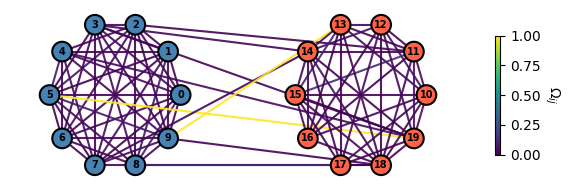

In [15]:
# --- GRÁFICA DE LA RED DAÑADA ---

# 1. Posiciones en dos círculos
N = 10
N_com = N
pos = {}
for i, node in enumerate(range(N_com)):
    angle = 2 * np.pi * i / N_com
    pos[node] = np.array([-1.5 + 0.8 * np.cos(angle), 0.8 * np.sin(angle)])
for i, node in enumerate(range(N_com, 2 * N_com)):
    angle = 2 * np.pi * i / N_com
    pos[node] = np.array([1.5 + 0.8 * np.cos(angle), 0.8 * np.sin(angle)])

# 2. Pesos de enlaces
edges = list(G.edges())
weights = np.array([Omega_damage_list[60][u, v] for u, v in edges])
w_max = weights.max() if weights.max() > 0 else 1

# 3. Dibujar
fig, ax = plt.subplots(figsize=(6, 2))

node_colors = ['steelblue'] * N_com + ['tomato'] * N_com
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=200, node_color=node_colors,
                       edgecolors='black', linewidths=1.5)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=7, font_weight='bold')
nx.draw_networkx_edges(G, pos, ax=ax, edgelist=edges,
                       width=1.5,
                       edge_color=weights, edge_cmap=plt.cm.viridis,
                       alpha=0.9, edge_vmin=0, edge_vmax=w_max)

# 4. Barra de color
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.7)
cbar.set_label(r'$\Omega_{ij}$', rotation=270, labelpad=15)
ax.axis('off')
plt.tight_layout()
plt.show()

## **REPARACIÓN DE LA RED**

In [4]:
# --- FUNCIONES DE REPARACIÓN ---
def probabilistic_repair_Omega(Omega_matrix, delta_r, beta):
    edges = np.argwhere(Omega_matrix > 0)
    Omega_values = np.array([Omega_matrix[i, j] for i, j in edges])

    # Solo considerar enlaces que aún no han llegado a 1
    mask = Omega_values < 1.0
    if not np.any(mask):
        return Omega_matrix  # todos los enlaces ya están reparados

    edges_reparables = edges[mask]
    Omega_reparables = Omega_values[mask]

    prob = (Omega_reparables ** beta) / np.sum(Omega_reparables ** beta)
    idx = np.random.choice(len(edges_reparables), p=prob)
    i, j = edges_reparables[idx]
    Omega_matrix[i, j] = min(Omega_matrix[i, j] + delta_r, 1.0)

    return Omega_matrix

# --- FUNCIONES DE SIMULACION ---

def Simulacion_repair(A, Omega_damage, T_repair, delta_r, beta):
    tau_0 = 1.0 / get_second_eigenvalue_real(A)
    Omega = Omega_damage.copy()  # <-- copia única antes del bucle
    funcionalidad = np.zeros(T_repair + 1)

    for T_step in range(T_repair + 1):
        xi2 = get_second_eigenvalue_real(Omega)
        tau_T = 1.0 / xi2
        funcionalidad[T_step] = tau_0 / tau_T

        if T_step < T_repair:
            Omega = probabilistic_repair_Omega(Omega, delta_r, beta)  # <-- evolución

    return funcionalidad, Omega


## $p=\frac{\Omega_{ij}^{\beta}}{\sum \Omega_{ij}^{\beta}}$

  Simulación 5/100 lista.
  Simulación 10/100 lista.
  Simulación 15/100 lista.
  Simulación 20/100 lista.
  Simulación 25/100 lista.
  Simulación 30/100 lista.
  Simulación 35/100 lista.
  Simulación 40/100 lista.
  Simulación 45/100 lista.
  Simulación 50/100 lista.
  Simulación 55/100 lista.
  Simulación 60/100 lista.
  Simulación 65/100 lista.
  Simulación 70/100 lista.
  Simulación 75/100 lista.
  Simulación 80/100 lista.
  Simulación 85/100 lista.
  Simulación 90/100 lista.
  Simulación 95/100 lista.
  Simulación 100/100 lista.

--- Tiempo total: 82.92 minutos ---


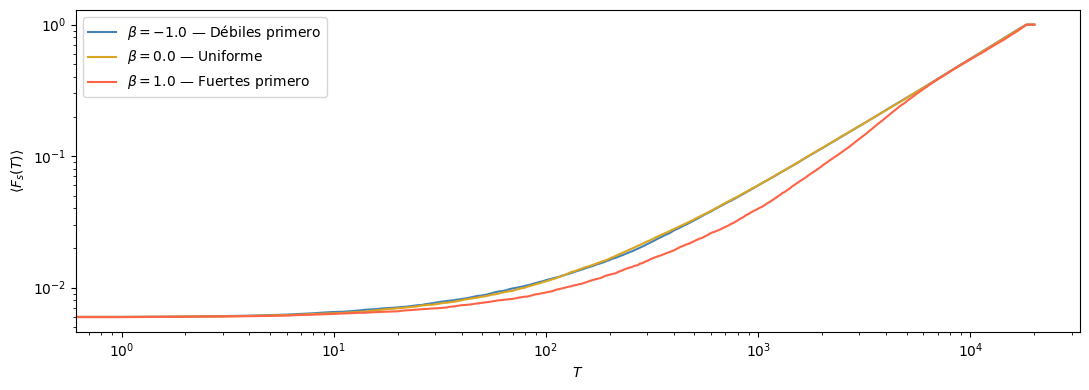

In [17]:
# --- PARÁMETROS ---
num_simulations = 100
T_repair = 20000
delta_r = 0.01
betas = np.array([-1.0, 0.0, 1.0])

beta_config = {
    -1: ("Débiles primero",  "steelblue"),
     0: ("Uniforme",         "goldenrod"),
     1: ("Fuertes primero",  "tomato"),
}

# --- ACUMULADORES ---
avg_repair = {b: np.zeros(T_repair + 1) for b in betas}

start_time_total = time.time()

# --- BUCLE DE SIMULACIONES ---
for sim in range(num_simulations):
    for b in betas:
        f_repair, _ = Simulacion_repair(A, Omega_damage_list[2], T_repair, delta_r, b)
        avg_repair[b] += f_repair

    if (sim + 1) % 5 == 0:
        print(f"  Simulación {sim+1}/{num_simulations} lista.")

# --- PROMEDIOS ---
for b in betas:
    avg_repair[b] /= num_simulations

print(f"\n--- Tiempo total: {(time.time() - start_time_total)/60:.2f} minutos ---")

# --- GRÁFICA ---
t_repair = np.arange(T_repair + 1)

plt.figure(figsize=(11, 4))
for b in betas:
    label, color = beta_config[b]
    plt.loglog(t_repair, avg_repair[b],
             color=color, linewidth=1.5, label=f'$\\beta = {b}$ — {label}')

plt.xlabel("$T$")
plt.ylabel(r"$\left\langle F_s(T) \right\rangle$")
plt.legend()
plt.tight_layout()
plt.show()

  Simulación 10/100 lista.
  Simulación 20/100 lista.
  Simulación 30/100 lista.
  Simulación 40/100 lista.
  Simulación 50/100 lista.
  Simulación 60/100 lista.
  Simulación 70/100 lista.
  Simulación 80/100 lista.
  Simulación 90/100 lista.
  Simulación 100/100 lista.

--- Tiempo total: 257.21 minutos ---


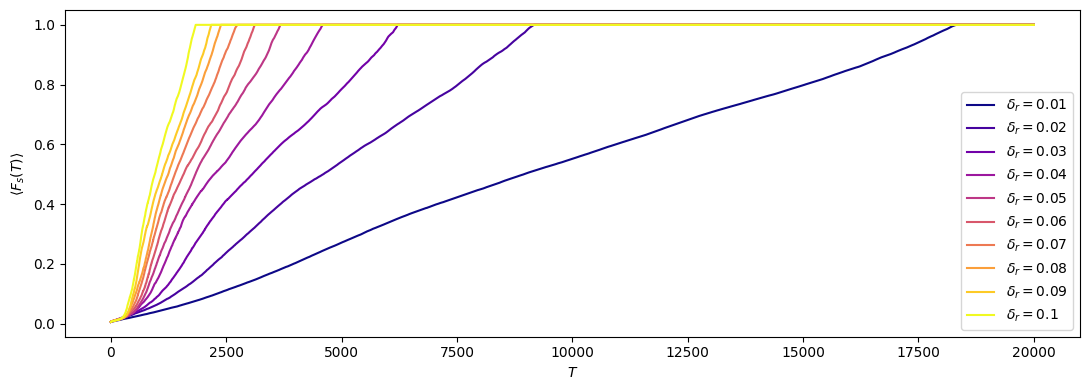

In [ ]:
# --- PARÁMETROS ---
num_simulations = 100
T_repair = 20000
beta = 1
deltas_r = np.array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1])

# --- ACUMULADORES ---
avg_repair = {d: np.zeros(T_repair + 1) for d in deltas_r}

start_time_total = time.time()

# --- BUCLE DE SIMULACIONES ---
for sim in range(num_simulations):
    for d in deltas_r:
        f_repair, _ = Simulacion_repair(A, Omega_damage_list[2], T_repair, d, beta)
        avg_repair[d] += f_repair

    if (sim + 1) % 10 == 0:
        print(f"  Simulación {sim+1}/{num_simulations} lista.")

# --- PROMEDIOS ---
for d in deltas_r:
    avg_repair[d] /= num_simulations

print(f"\n--- Tiempo total: {(time.time() - start_time_total)/60:.2f} minutos ---")

np.save('F_Prob.npy',avg_repair) ## GUARDAR DATOS

# --- GRÁFICA ---
t_repair = np.arange(T_repair + 1)

colormap = plt.colormaps.get_cmap('plasma')
norm = plt.Normalize(vmin=deltas_r.min(), vmax=deltas_r.max())

plt.figure(figsize=(11, 4))
for d in deltas_r:
    color = colormap(norm(d))
    plt.plot(t_repair, avg_repair[d],
             color=color, linewidth=1.5, label=f'$\\delta_r = {d}$')

plt.xlabel("$T$")
plt.ylabel(r"$\left\langle F_s(T) \right\rangle$")
plt.legend()
plt.tight_layout()
plt.show()

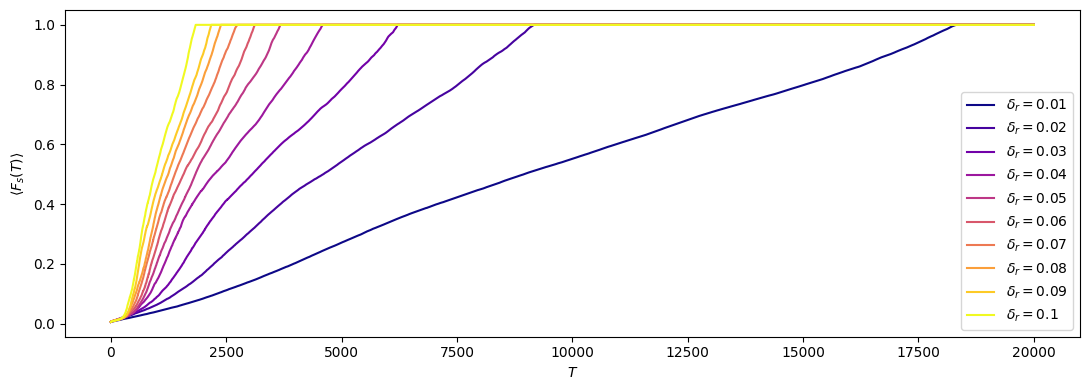

In [6]:

avg_repair = np.load('F_Prob.npy', allow_pickle=True).item()

T_repair = 20000
deltas_r = np.array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1])

# --- GRÁFICA ---
t_repair = np.arange(T_repair + 1)

colormap = plt.colormaps.get_cmap('plasma')
norm = plt.Normalize(vmin=deltas_r.min(), vmax=deltas_r.max())

plt.figure(figsize=(11, 4))
for d in deltas_r:
    color = colormap(norm(d))
    plt.plot(t_repair, avg_repair[d],
             color=color, linewidth=1.5, label=f'$\\delta_r = {d}$')

plt.xlabel("$T$")
plt.ylabel(r"$\left\langle F_s(T) \right\rangle$")
plt.legend()
plt.tight_layout()
plt.show()

## REPARACIÓN DETERMINISTA

In [7]:
def deterministic_repair_Omega(Omega_matrix, delta_r, strategy='best'):
    """
    Repara determinísticamente un enlace dañado.
    strategy = 'best'  : repara el enlace en mejor estado (mayor Omega_ij)
    strategy = 'worst' : repara el enlace en peor estado  (menor Omega_ij)
    """
    edges = np.argwhere(Omega_matrix > 0)
    Omega_values = np.array([Omega_matrix[i, j] for i, j in edges])

    mask = Omega_values < 1.0
    if not np.any(mask):
        return Omega_matrix

    edges_reparables = edges[mask]
    Omega_reparables = Omega_values[mask]

    if strategy == 'best':
        idx = np.argmax(Omega_reparables)
    elif strategy == 'worst':
        idx = np.argmin(Omega_reparables)

    i, j = edges_reparables[idx]
    Omega_matrix[i, j] = min(Omega_matrix[i, j] + delta_r, 1.0)

    return Omega_matrix


def Simulacion_repair_deterministic(A, Omega_damage, T_repair, delta_r, strategy='best'):
    tau_0 = 1.0 / get_second_eigenvalue_real(A)
    Omega = Omega_damage.copy()
    funcionalidad = np.zeros(T_repair + 1)

    for T_step in range(T_repair + 1):
        xi2 = get_second_eigenvalue_real(Omega)
        tau_T = 1.0 / xi2
        funcionalidad[T_step] = tau_0 / tau_T

        if T_step < T_repair:
            Omega = deterministic_repair_Omega(Omega, delta_r, strategy)

    return funcionalidad, Omega

  Simulación 10/1000 lista.
  Simulación 20/1000 lista.
  Simulación 30/1000 lista.
  Simulación 40/1000 lista.
  Simulación 50/1000 lista.
  Simulación 60/1000 lista.
  Simulación 70/1000 lista.
  Simulación 80/1000 lista.
  Simulación 90/1000 lista.
  Simulación 100/1000 lista.
  Simulación 110/1000 lista.
  Simulación 120/1000 lista.
  Simulación 130/1000 lista.
  Simulación 140/1000 lista.
  Simulación 150/1000 lista.
  Simulación 160/1000 lista.
  Simulación 170/1000 lista.
  Simulación 180/1000 lista.
  Simulación 190/1000 lista.
  Simulación 200/1000 lista.
  Simulación 210/1000 lista.
  Simulación 220/1000 lista.
  Simulación 230/1000 lista.
  Simulación 240/1000 lista.
  Simulación 250/1000 lista.
  Simulación 260/1000 lista.
  Simulación 270/1000 lista.
  Simulación 280/1000 lista.
  Simulación 290/1000 lista.
  Simulación 300/1000 lista.
  Simulación 310/1000 lista.
  Simulación 320/1000 lista.
  Simulación 330/1000 lista.
  Simulación 340/1000 lista.
  Simulación 350/1000 l

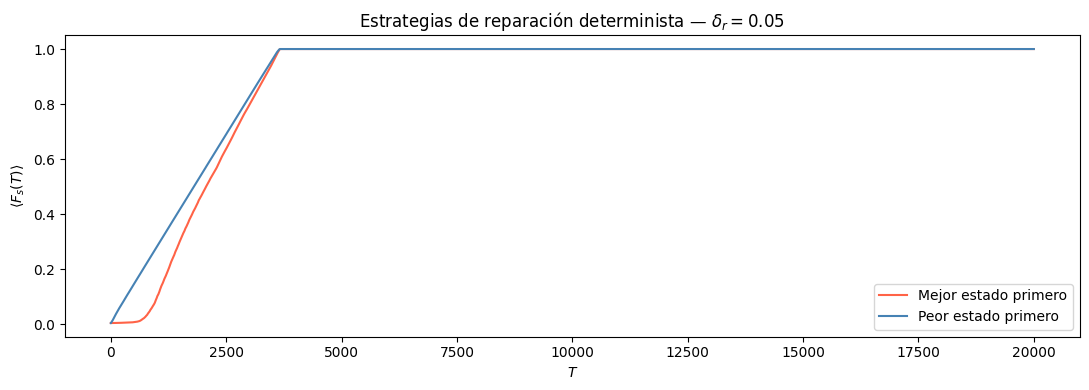

In [ ]:
# --- PARÁMETROS ---
T_repair = 20000
delta_r = 0.05
strategies = ['best', 'worst']

strategy_config = {
    'best':  ('Mejor estado primero', 'tomato'),
    'worst': ('Peor estado primero',  'steelblue'),
}

# --- ACUMULADORES ---
avg_repair = {s: np.zeros(T_repair + 1) for s in strategies}

start_time_total = time.time()

# --- BUCLE DE SIMULACIONES ---
for sim, Omega_damage in enumerate(Omega_damage_list):
    for s in strategies:
        f_repair, _ = Simulacion_repair_deterministic(A, Omega_damage, T_repair, delta_r, strategy=s)
        avg_repair[s] += f_repair

    if (sim + 1) % 10 == 0:
        print(f"  Simulación {sim+1}/{len(Omega_damage_list)} lista.")

# --- PROMEDIOS ---
for s in strategies:
    avg_repair[s] /= len(Omega_damage_list)

print(f"\n--- Tiempo total: {(time.time() - start_time_total)/60:.2f} minutos ---")

#np.save('F_Deterministic1.npy',avg_repair) ## GUARDAR DATOS

# --- GRÁFICA ---
t_repair = np.arange(T_repair + 1)

plt.figure(figsize=(11, 4))
for s in strategies:
    label, color = strategy_config[s]
    plt.plot(t_repair, avg_repair[s],
             color=color, linewidth=1.5, label=label)

plt.xlabel("$T$")
plt.ylabel(r"$\left\langle F_s(T) \right\rangle$")
plt.title(f"Estrategias de reparación determinista — $\\delta_r = {delta_r}$")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# --- PARÁMETROS ---
T_repair = 20000
deltas_r = np.linspace(0.01, 0.1, 10)

# --- ACUMULADORES ---
avg_repair = {d: np.zeros(T_repair + 1) for d in deltas_r}

start_time_total = time.time()

# --- BUCLE DE SIMULACIONES ---
for sim, Omega_damage in enumerate(Omega_damage_list):
    for d in deltas_r:
        f_repair, _ = Simulacion_repair_deterministic(A, Omega_damage, T_repair, d, strategy='best')
        avg_repair[d] += f_repair

    if (sim + 1) % 10 == 0:
        print(f"  Simulación {sim+1}/{len(Omega_damage_list)} lista.")

# --- PROMEDIOS ---
for d in deltas_r:
    avg_repair[d] /= len(Omega_damage_list)

print(f"\n--- Tiempo total: {(time.time() - start_time_total)/60:.2f} minutos ---")

np.save('F_Deterministic1.npy',avg_repair) ## GUARDAR DATOS

# --- GRÁFICA ---
t_repair = np.arange(T_repair + 1)

colormap = plt.colormaps.get_cmap('plasma')
norm = plt.Normalize(vmin=deltas_r.min(), vmax=deltas_r.max())

plt.figure(figsize=(11, 4))
for d in deltas_r:
    color = colormap(norm(d))
    plt.plot(t_repair, avg_repair[d],
             color=color, linewidth=1.5, label=f'$\\delta_r = {d:.2f}$')

sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('$\\delta_r$')

plt.xlabel("$T$")
plt.ylabel(r"$\left\langle F_s(T) \right\rangle$")
plt.tight_layout()
plt.show()

  Simulación 10/1000 lista.
  Simulación 20/1000 lista.
  Simulación 30/1000 lista.
  Simulación 40/1000 lista.
  Simulación 50/1000 lista.
  Simulación 60/1000 lista.
  Simulación 70/1000 lista.
  Simulación 80/1000 lista.
  Simulación 90/1000 lista.
  Simulación 100/1000 lista.
  Simulación 110/1000 lista.
  Simulación 120/1000 lista.
  Simulación 130/1000 lista.
  Simulación 140/1000 lista.
  Simulación 150/1000 lista.
  Simulación 160/1000 lista.
  Simulación 170/1000 lista.
  Simulación 180/1000 lista.
  Simulación 190/1000 lista.
  Simulación 200/1000 lista.
  Simulación 210/1000 lista.
  Simulación 220/1000 lista.
  Simulación 230/1000 lista.
  Simulación 240/1000 lista.
  Simulación 250/1000 lista.
  Simulación 260/1000 lista.
  Simulación 270/1000 lista.
  Simulación 280/1000 lista.
  Simulación 290/1000 lista.
  Simulación 300/1000 lista.
  Simulación 310/1000 lista.
  Simulación 320/1000 lista.
  Simulación 330/1000 lista.
  Simulación 340/1000 lista.
  Simulación 350/1000 l

KeyboardInterrupt: 

In [13]:
np.save('F_Deterministic1.npy',avg_repair) ## GUARDAR DATOS

## REPARANDO ENLACE POR ENLACE

In [10]:
def _seleccionar_enlace(Omega_matrix, strategy):
    """
    Devuelve las coordenadas (i, j) del enlace a reparar según strategy.
    Retorna None si no hay enlaces dañados.
    """
    edges = np.argwhere(Omega_matrix > 0)
    Omega_values = np.array([Omega_matrix[i, j] for i, j in edges])

    mask = Omega_values < 1.0
    if not np.any(mask):
        return None

    edges_reparables = edges[mask]
    Omega_reparables = Omega_values[mask]

    if strategy == 'best':
        idx = np.argmax(Omega_reparables)
    elif strategy == 'worst':
        idx = np.argmin(Omega_reparables)

    return edges_reparables[idx]

def Simulacion_repair_deterministic(A, Omega_damage, T_repair, delta_r, strategy='best'):
    tau_0 = 1.0 / get_second_eigenvalue_real(A)
    Omega = Omega_damage.copy()
    funcionalidad = np.zeros(T_repair + 1)

    # Variables para trackear el máximo
    F_max = -np.inf
    Omega_at_Fmax = Omega.copy()

    enlace_actual = _seleccionar_enlace(Omega, strategy)

    for T_step in range(T_repair + 1):
        xi2 = get_second_eigenvalue_real(Omega)
        tau_T = 1.0 / xi2
        F_s = tau_0 / tau_T
        funcionalidad[T_step] = F_s

        # Guardar Omega si es el máximo hasta ahora
        if F_s > F_max:
            F_max = F_s
            Omega_at_Fmax = Omega.copy()

        if T_step < T_repair:
            if enlace_actual is None:
                funcionalidad[T_step + 1:] = funcionalidad[T_step]
                break

            i, j = enlace_actual
            Omega[i, j] = min(Omega[i, j] + delta_r, 1.0)

            if Omega[i, j] >= 1.0:
                enlace_actual = _seleccionar_enlace(Omega, strategy)

    return funcionalidad, Omega_at_Fmax, F_max




  Simulación 10/1000 lista.
  Simulación 20/1000 lista.
  Simulación 30/1000 lista.
  Simulación 40/1000 lista.
  Simulación 50/1000 lista.
  Simulación 60/1000 lista.
  Simulación 70/1000 lista.
  Simulación 80/1000 lista.
  Simulación 90/1000 lista.
  Simulación 100/1000 lista.
  Simulación 110/1000 lista.
  Simulación 120/1000 lista.
  Simulación 130/1000 lista.
  Simulación 140/1000 lista.
  Simulación 150/1000 lista.
  Simulación 160/1000 lista.
  Simulación 170/1000 lista.
  Simulación 180/1000 lista.
  Simulación 190/1000 lista.
  Simulación 200/1000 lista.
  Simulación 210/1000 lista.
  Simulación 220/1000 lista.
  Simulación 230/1000 lista.
  Simulación 240/1000 lista.
  Simulación 250/1000 lista.
  Simulación 260/1000 lista.
  Simulación 270/1000 lista.
  Simulación 280/1000 lista.
  Simulación 290/1000 lista.
  Simulación 300/1000 lista.
  Simulación 310/1000 lista.
  Simulación 320/1000 lista.
  Simulación 330/1000 lista.
  Simulación 340/1000 lista.
  Simulación 350/1000 l

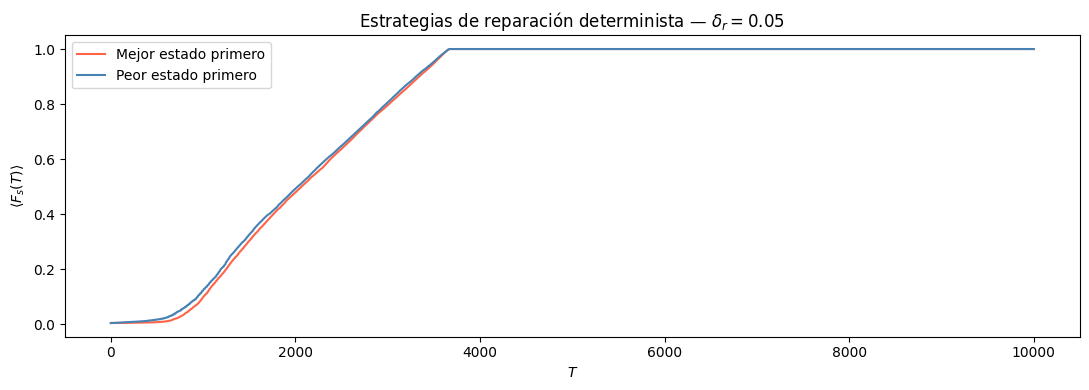

In [19]:
# --- PARÁMETROS ---
T_repair = 10000
delta_r = 0.05
strategies = ['best', 'worst']

strategy_config = {
    'best':  ('Mejor estado primero', 'tomato'),
    'worst': ('Peor estado primero',  'steelblue'),
}

# --- ACUMULADORES ---
avg_repair = {s: np.zeros(T_repair + 1) for s in strategies}

start_time_total = time.time()

# --- BUCLE DE SIMULACIONES ---
for sim, Omega_damage in enumerate(Omega_damage_list):
    for s in strategies:
        f_repair, _, _ = Simulacion_repair_deterministic(A, Omega_damage, T_repair, delta_r, strategy=s)
        avg_repair[s] += f_repair

    if (sim + 1) % 10 == 0:
        print(f"  Simulación {sim+1}/{len(Omega_damage_list)} lista.")

# --- PROMEDIOS ---
for s in strategies:
    avg_repair[s] /= len(Omega_damage_list)

print(f"\n--- Tiempo total: {(time.time() - start_time_total)/60:.2f} minutos ---")

# --- GRÁFICA ---
t_repair = np.arange(T_repair + 1)

plt.figure(figsize=(11, 4))
for s in strategies:
    label, color = strategy_config[s]
    plt.plot(t_repair, avg_repair[s],
             color=color, linewidth=1.5, label=label)

plt.xlabel("$T$")
plt.ylabel(r"$\left\langle F_s(T) \right\rangle$")
plt.title(f"Estrategias de reparación determinista — $\\delta_r = {delta_r}$")
plt.legend()
plt.tight_layout()
plt.show()

  Simulación 10/1000 lista.
  Simulación 20/1000 lista.
  Simulación 30/1000 lista.
  Simulación 40/1000 lista.
  Simulación 50/1000 lista.
  Simulación 60/1000 lista.
  Simulación 70/1000 lista.
  Simulación 80/1000 lista.
  Simulación 90/1000 lista.
  Simulación 100/1000 lista.
  Simulación 110/1000 lista.
  Simulación 120/1000 lista.
  Simulación 130/1000 lista.
  Simulación 140/1000 lista.
  Simulación 150/1000 lista.
  Simulación 160/1000 lista.
  Simulación 170/1000 lista.
  Simulación 180/1000 lista.
  Simulación 190/1000 lista.
  Simulación 200/1000 lista.
  Simulación 210/1000 lista.
  Simulación 220/1000 lista.
  Simulación 230/1000 lista.
  Simulación 240/1000 lista.
  Simulación 250/1000 lista.
  Simulación 260/1000 lista.
  Simulación 270/1000 lista.
  Simulación 280/1000 lista.
  Simulación 290/1000 lista.
  Simulación 300/1000 lista.
  Simulación 310/1000 lista.
  Simulación 320/1000 lista.
  Simulación 330/1000 lista.
  Simulación 340/1000 lista.
  Simulación 350/1000 l

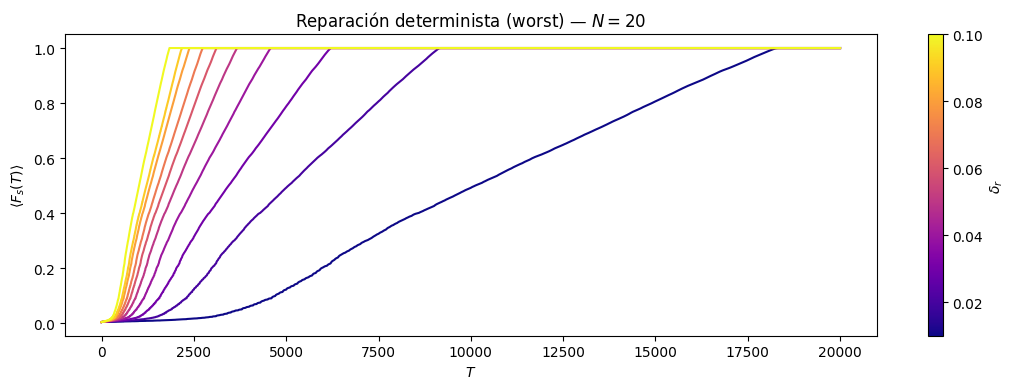

In [11]:
# --- PARÁMETROS ---
T_repair = 20000
deltas_r = np.linspace(0.01, 0.1, 10)

# --- ACUMULADORES ---
avg_repair = {d: np.zeros(T_repair + 1) for d in deltas_r}

start_time_total = time.time()

# --- BUCLE DE SIMULACIONES ---
for sim, Omega_damage in enumerate(Omega_damage_list):
    for d in deltas_r:
        f_repair, _, _ = Simulacion_repair_deterministic(A, Omega_damage, T_repair, d, strategy='worst')
        avg_repair[d] += f_repair

    if (sim + 1) % 10 == 0:
        print(f"  Simulación {sim+1}/{len(Omega_damage_list)} lista.")

# --- PROMEDIOS ---
for d in deltas_r:
    avg_repair[d] /= len(Omega_damage_list)

print(f"\n--- Tiempo total: {(time.time() - start_time_total)/60:.2f} minutos ---")

# --- GRÁFICA ---
t_repair = np.arange(T_repair + 1)

colormap = plt.colormaps.get_cmap('plasma')
norm = plt.Normalize(vmin=deltas_r.min(), vmax=deltas_r.max())

plt.figure(figsize=(11, 4))
for d in deltas_r:
    color = colormap(norm(d))
    plt.plot(t_repair, avg_repair[d],
             color=color, linewidth=1.5)

sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('$\\delta_r$')

plt.xlabel("$T$")
plt.ylabel(r"$\left\langle F_s(T) \right\rangle$")
plt.title(f"Reparación determinista (worst) — $N = {2*N}$")
plt.tight_layout()
plt.show()

## EDGE BETWEENESS


In [13]:
def _seleccionar_enlace2(Omega_matrix, strategy, G):
    """
    Devuelve las coordenadas (i, j) del enlace a reparar según strategy.
    Retorna None si no hay enlaces dañados.
    strategy = 'high_betweenness' : mayor edge betweenness
    strategy = 'low_betweenness'  : menor edge betweenness
    """
    edges = np.argwhere(Omega_matrix > 0)
    Omega_values = np.array([Omega_matrix[i, j] for i, j in edges])

    mask = Omega_values < 1.0
    if not np.any(mask):
        return None

    edges_reparables = edges[mask]
    Omega_reparables = Omega_values[mask]


    # Calcular betweenness de todos los enlaces activos
    betweenness = nx.edge_betweenness_centrality(G)

    # Obtener betweenness solo para los enlaces reparables
    bw_values = np.array([
        betweenness.get((i, j), betweenness.get((j, i), 0.0))
        for i, j in edges_reparables
    ])

    if strategy == 'high_betweenness':
        idx = np.argmax(bw_values)
    elif strategy == 'low_betweenness':
        idx = np.argmin(bw_values)

    return edges_reparables[idx]

def Simulacion_repair_deterministic2(A, G, Omega_damage, T_repair, delta_r, strategy='best'):
    tau_0 = 1.0 / get_second_eigenvalue_real(A)
    Omega = Omega_damage.copy()
    funcionalidad = np.zeros(T_repair + 1)

    F_max = -np.inf
    Omega_at_Fmax = Omega.copy()

    enlace_actual = _seleccionar_enlace2(Omega, strategy, G)

    for T_step in range(T_repair + 1):
        xi2 = get_second_eigenvalue_real(Omega)
        tau_T = 1.0 / xi2
        F_s = tau_0 / tau_T
        funcionalidad[T_step] = F_s

        if F_s > F_max:
            F_max = F_s
            Omega_at_Fmax = Omega.copy()

        if T_step < T_repair:
            if enlace_actual is None:
                funcionalidad[T_step + 1:] = funcionalidad[T_step]
                break

            i, j = enlace_actual
            Omega[i, j] = min(Omega[i, j] + delta_r, 1.0)

            if Omega[i, j] >= 1.0:
                enlace_actual = _seleccionar_enlace2(Omega, strategy, G)

    return funcionalidad, Omega_at_Fmax, F_max


--- Tiempo total: 0.05 minutos ---


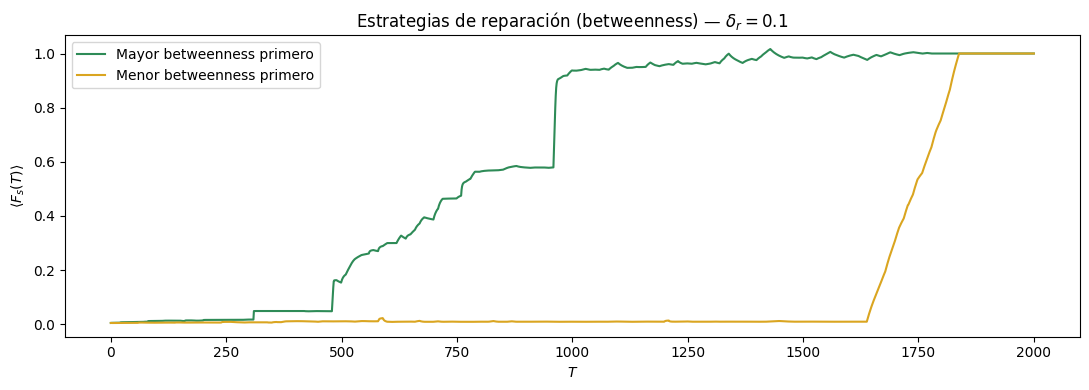

In [14]:
# --- PARÁMETROS ---
T_repair = 2000
delta_r = 0.1
strategies = ['high_betweenness', 'low_betweenness']

strategy_config = {
    'high_betweenness': ('Mayor betweenness primero', 'seagreen'),
    'low_betweenness':  ('Menor betweenness primero', 'goldenrod'),
}

# --- ACUMULADORES ---
avg_repair = {s: np.zeros(T_repair + 1) for s in strategies}

start_time_total = time.time()

# --- BUCLE DE SIMULACIONES ---
for sim, Omega_damage in enumerate(Omega_damage_list[0:1]):
    for s in strategies:
        f_repair, _, _ = Simulacion_repair_deterministic2(
            A, G, Omega_damage, T_repair, delta_r, strategy=s
        )
        avg_repair[s] += f_repair

    if (sim + 1) % 10 == 0:
        print(f"  Simulación {sim+1}/{len(Omega_damage_list[0:1])} lista.")

# --- PROMEDIOS ---
for s in strategies:
    avg_repair[s] /= len(Omega_damage_list[0:1])

print(f"\n--- Tiempo total: {(time.time() - start_time_total)/60:.2f} minutos ---")

# --- GRÁFICA ---
t_repair = np.arange(T_repair + 1)

plt.figure(figsize=(11, 4))
for s in strategies:
    label, color = strategy_config[s]
    plt.plot(t_repair, avg_repair[s],
             color=color, linewidth=1.5, label=label)

plt.xlabel("$T$")
plt.ylabel(r"$\left\langle F_s(T) \right\rangle$")
plt.title(f"Estrategias de reparación (betweenness) — $\\delta_r = {delta_r}$")
plt.legend()
plt.tight_layout()
plt.show()


--- Tiempo total: 0.72 minutos ---


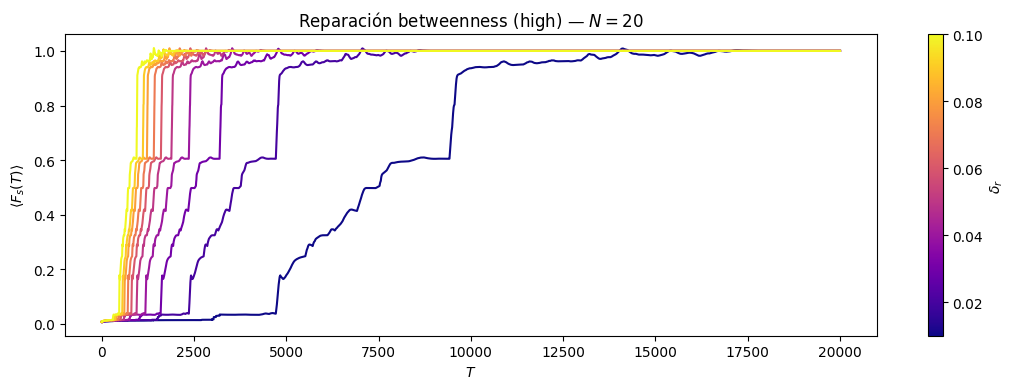

In [ ]:
# --- PARÁMETROS ---
T_repair = 20000
deltas_r = np.linspace(0.01, 0.1, 10)

# --- ACUMULADORES ---
avg_repair = {d: np.zeros(T_repair + 1) for d in deltas_r}

start_time_total = time.time()

# --- BUCLE DE SIMULACIONES ---
for sim, Omega_damage in enumerate(Omega_damage_list):
    for d in deltas_r:
        f_repair, _, _ = Simulacion_repair_deterministic2(A, G, Omega_damage, T_repair, d, strategy='high_betweenness')
        avg_repair[d] += f_repair

    if (sim + 1) % 10 == 0:
        print(f"  Simulación {sim+1}/{len(Omega_damage_list)} lista.")

# --- PROMEDIOS ---
for d in deltas_r:
    avg_repair[d] /= len(Omega_damage_list)

print(f"\n--- Tiempo total: {(time.time() - start_time_total)/60:.2f} minutos ---")

# --- GRÁFICA ---
t_repair = np.arange(T_repair + 1)

colormap = plt.colormaps.get_cmap('plasma')
norm = plt.Normalize(vmin=deltas_r.min(), vmax=deltas_r.max())

plt.figure(figsize=(11, 4))
for d in deltas_r:
    color = colormap(norm(d))
    plt.plot(t_repair, avg_repair[d],
             color=color, linewidth=1.5)

sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('$\\delta_r$')

plt.xlabel("$T$")
plt.ylabel(r"$\left\langle F_s(T) \right\rangle$")
plt.title(f"Reparación betweenness (high) — $N = {2*N}$")
plt.tight_layout()
plt.show()